# Energy-Based Models (EBMs)

Neste notebook, exploraremos os **Energy-Based Models (EBMs)**, ou Modelos Baseados em Energia. Ao contrário de modelos baseados em verossimilhança explícita (como Normalizing Flows e VAEs) ou modelos adversários (GANs), os EBMs não assumem uma parametrização direta para gerar amostras. Em vez disso, eles definem uma função de energia escalar que atribui valores baixos para regiões de alta densidade de dados (altamente prováveis) e valores altos para o resto do espaço.

Estruturamos este aprendizado em duas seções principais:
* **Exemplo Conceitual (make_moons):** Onde visualizaremos fisicamente a superfície de energia tridimensional e como as partículas migram para os vales de menor energia durante a amostragem.
* **Aplicação em Imagens (MNIST):** Onde aplicaremos os EBMs para modelar e gerar dígitos manuscritos de dimensão $28 \times 28$ ($784$ dimensões) utilizando um buffer persistente de amostras.

## Fundamentos

Modelos Baseados em Energia (**EBMs**) são motivados pela mecânica estatística. Em física, a probabilidade de um sistema físico estar em um determinado estado de energia $E(x)$ é descrita pela **distribuição de Boltzmann** (também conhecida como **distribuição de Gibbs**).

Adaptando essa intuição para modelagem generativa, podemos expressar a densidade de probabilidade $p_\theta(x)$ de qualquer vetor de dados $x$ em termos de uma função de energia escalar não normalizada $E_\theta(x) \in \mathbb{R}$:

$$
p_\theta(x) = \frac{\exp(-E_\theta(x))}{Z(\theta)}
$$

Onde $Z(\theta)$ é a **função de partição** (constante de normalização), definida como a integral sobre todo o espaço de entrada:

$$
Z(\theta) = \int \exp(-E_\theta(x)) \, dx
$$

Em espaços de alta dimensão (como imagens), calcular a integral $Z(\theta)$ é intratável. Por isso, os EBMs focam em aprender o formato da superfície de energia diretamente, sem a necessidade de calcular $Z(\theta)$ explicitamente.

### O Gradiente do Log-Likelihood e a Divergência Contrastiva

Para treinar o modelo por máxima verossimilhança sem calcular $Z(\theta)$, calculamos o gradiente do log-likelihood negativo (NLL) em relação aos parâmetros $\theta$. Usando a regra da cadeia, o gradiente para um dado real $x$ é:

$$
\nabla_\theta \mathcal{L}(\theta) = \nabla_\theta E_\theta(x) - \mathbb{E}_{\tilde{x} \sim p_\theta(\tilde{x})} [\nabla_\theta E_\theta(\tilde{x})]
$$

Esse gradiente possui uma interpretação física intuitiva:
1. **Fase Positiva (Dados Reais):** Minimiza a energia $E_\theta(x)$ das amostras reais do dataset (primeiro termo), puxando para baixo a energia em regiões reais.
2. **Fase Negativa (Amostras do Modelo):** Maximiza a energia $E_\theta(\tilde{x})$ de amostras $\tilde{x}$ geradas pelo modelo (segundo termo), empurrando para cima a energia em regiões falsas.

### Amostragem por Langevin Dynamics (SGLD)

Para obter amostras falsas $\tilde{x} \sim p_\theta$ sem calcular $Z(\theta)$, usamos **Stochastic Gradient Langevin Dynamics (SGLD)**. Esse método realiza passos de descida de gradiente na própria função de energia em relação à entrada $x$, adicionando ruído gaussiano para garantir a exploração do espaço:

$$
x_{t+1} = x_t - \frac{\alpha}{2} \nabla_x E_\theta(x_t) + \epsilon \quad \text{onde} \quad \epsilon \sim \mathcal{N}(0, \alpha I)
$$

Onde $\alpha$ é o tamanho do passo de Langevin. À medida que o número de passos tende ao infinito ($t \to \infty$), a distribuição das amostras converge exatamente para $p_\theta(x)$.

## Imports e Configuração Básica

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

In [33]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Exemplo Conceitual (make_moons)

Nesta seção, utilizaremos a distribuição clássica bidimensional **make_moons**. Por possuir apenas 2 dimensões ($x \in \mathbb{R}^2$), ela nos permite visualizar a função de energia $E_\theta(x)$ como uma superfície 3D e observar o SGLD agindo sobre os pontos no plano bidimensional.

### Preparação dos Dados

Vamos gerar e visualizar o dataset bidimensional das duas luas para treinar o nosso modelo de energia.

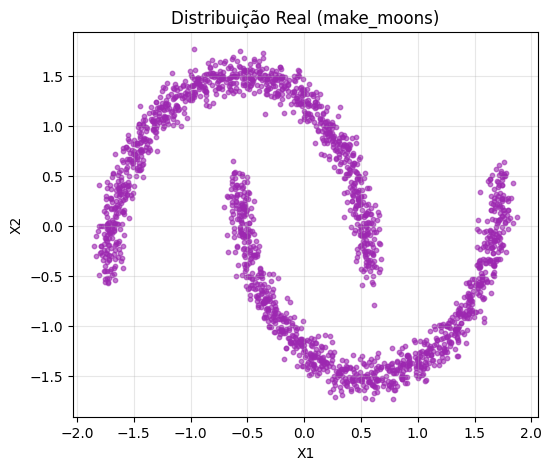

In [56]:
# Gerar dados das duas luas
X_np, _ = make_moons(n_samples=2000, noise=0.05, random_state=42)

# Normalizar para estabilizar o treinamento (média=0, std=1)
mean = X_np.mean(axis=0)
std = X_np.std(axis=0)
X_np = (X_np - mean) / std

X_tensor = torch.tensor(X_np, dtype=torch.float32)
moons_dataset = TensorDataset(X_tensor)
moons_dataloader = DataLoader(moons_dataset, batch_size=256, shuffle=True)

# Visualizar a distribuição real
plt.figure(figsize=(6, 5))
plt.scatter(X_np[:, 0], X_np[:, 1], s=10, alpha=0.6, color='#9c27b0')
plt.title("Distribuição Real (make_moons)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True, alpha=0.3)
plt.show()

### Arquitetura do Modelo

A arquitetura do modelo de energia mapeia uma entrada bidimensional $x \in \mathbb{R}^2$ para uma saída escalar de energia $E_\theta(x) \in \mathbb{R}$. Usaremos uma rede totalmente conectada (MLP) com camadas ocultas de dimensão $128$ e ativações suaves `SiLU`.

Em EBMs, evitamos o uso de ativações clássicas `ReLU`. Como computamos o gradiente da energia com relação à entrada $\nabla_x E_\theta(x)$ para realizar amostragem, precisamos de uma rede cujas derivadas sejam contínuas. A ativação `SiLU` (Swish) possui primeira e segunda derivadas suaves em toda parte, o que facilita o comportamento dinâmico do Langevin Dynamics.

In [57]:
class EnergyModel2D(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),   # Entrada: batch_size x 2
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)    # Saída escalar de energia: batch_size x 1
        )
        
    def forward(self, x):
        return self.net(x)

### Amostragem SGLD

Implementamos a amostragem iterativa Langevin. Partimos de uma distribuição uniforme simples (ruído no plano) e realizamos passos de descida de gradiente na energia com ruído Gaussiano aditivo.

In [87]:
def sgld_sample_2d(model, x_start, steps=60, step_size=0.2, noise_std=0.05):
    """
    Realiza a amostragem SGLD a partir de um estado inicial x_start.
    """
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
        
    x = x_start.clone().detach().requires_grad_(True)
    
    for _ in range(steps):
        energy = model(x)
        # Calcula o gradiente da energia em relação à entrada x
        grad = torch.autograd.grad(energy.sum(), x)[0]
        
        # Langevin step
        noise = torch.randn_like(x) * noise_std
        x.data = x.data - 0.5 * step_size * grad + noise
        
    for p in model.parameters():
        p.requires_grad = True
    model.train()
    return x.detach()

### Buffer Persistente de Amostras

Para garantir que a amostragem do Langevin Dynamics (SGLD) seja eficiente e converja rapidamente durante o treinamento, utilizamos um **Buffer Persistente de Amostras** (proposto por Du & Mordatch, 2019). Em vez de iniciar a amostragem SGLD a partir de puro ruído aleatório em todas as iterações, mantemos um conjunto de amostras na memória (buffer). Em cada passo:
1. Sorteamos amostras do buffer e corremos o SGLD por apenas alguns passos (ex: 60 passos).
2. Escrevemos as novas amostras geradas de volta no mesmo lugar do buffer.
3. Para garantir a exploração global de novas regiões e evitar que o buffer fique viciado, reinicializamos 5% das amostras com puro ruído a cada passo.

In [88]:
class SGLDBuffer:
    def __init__(self, buffer_size=8192, shape=(2,), reinit_prob=0.05, range_min=-3.0, range_max=3.0):
        self.buffer_size = buffer_size
        self.shape = shape
        self.reinit_prob = reinit_prob
        self.range_min = range_min
        self.range_max = range_max
        # Mantém o buffer na memória CPU para economizar VRAM da GPU
        self.buffer = torch.rand(buffer_size, *shape) * (range_max - range_min) + range_min
        
    def sample(self, batch_size, device):
        # Seleciona índices aleatórios no buffer
        indices = torch.randint(0, self.buffer_size, (batch_size,))
        samples = self.buffer[indices].to(device)
        
        # Reinicializa amostras com ruído baseado na reinit_prob
        reinit_mask = torch.rand(batch_size) < self.reinit_prob
        if reinit_mask.any():
            samples[reinit_mask] = (torch.rand(reinit_mask.sum(), *self.shape) * (self.range_max - self.range_min) + self.range_min).to(device)
            
        return samples, indices
    
    def update(self, samples, indices):
        self.buffer[indices] = samples.detach().cpu()

### Otimização e Treinamento

A função de perda utilizada é a **Divergência Contrastiva** (CD), definida como:

$$
\mathcal{L}_{CD}(\theta) = E_\theta(x_{real}) - E_\theta(x_{fake})
$$

Para garantir a estabilidade numérica do treinamento, adicionamos uma regularização $L_2$ sobre os valores de energia:

$$
\mathcal{L}_{reg}(\theta) = \lambda (E_\theta(x_{real})^2 + E_\theta(x_{fake})^2)
$$

Onde $\lambda = 0.01$ é o coeficiente de regularização. A perda total a ser minimizada é:

$$
\mathcal{L}(\theta) = \mathcal{L}_{CD}(\theta) + \mathcal{L}_{reg}(\theta)
$$

In [127]:
model_2d = EnergyModel2D().to(device)
optimizer_2d = optim.Adam(model_2d.parameters(), lr=1e-3, weight_decay=1e-4)
buffer_2d = SGLDBuffer(buffer_size=4096, shape=(2,), range_min=-1.5, range_max=1.5)

In [128]:
num_epochs_2d = 200
losses_2d = []
generated_samples_history = []

for epoch in range(1, num_epochs_2d + 1):
    epoch_loss = 0
    for (real_x,) in moons_dataloader:
        real_x = real_x.to(device)
        batch_sz = real_x.shape[0]
        
        # Fase Negativa: Obter amostras iniciais do buffer e rodar SGLD
        x_start, indices = buffer_2d.sample(batch_sz, device)
        fake_x = sgld_sample_2d(model_2d, x_start, steps=30, step_size=0.2, noise_std=0.005)
        buffer_2d.update(fake_x, indices)
        
        optimizer_2d.zero_grad()
        
        energy_real = model_2d(real_x)
        energy_fake = model_2d(fake_x)
        
        # CD Loss
        cd_loss = energy_real.mean() - energy_fake.mean()
        # Regularização L2 na magnitude de energia
        reg_loss = 0.01 * (energy_real**2 + energy_fake**2).mean()
        
        loss = cd_loss + reg_loss
        loss.backward()
        optimizer_2d.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(moons_dataloader)
    losses_2d.append(avg_loss)
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"[{epoch}/{num_epochs_2d}] Loss: {avg_loss:.4f}")

    samples, _ = buffer_2d.sample(500, device)
    samples = samples.cpu().numpy()
    generated_samples_history.append((epoch, samples))

[1/200] Loss: 0.0028
[10/200] Loss: 0.0013
[20/200] Loss: 0.0039
[30/200] Loss: 0.0021
[40/200] Loss: 0.0011
[50/200] Loss: -0.0002
[60/200] Loss: 0.0014
[70/200] Loss: 0.0004
[80/200] Loss: 0.0002
[90/200] Loss: -0.0000
[100/200] Loss: 0.0002
[110/200] Loss: -0.0000
[120/200] Loss: -0.0003
[130/200] Loss: 0.0002
[140/200] Loss: 0.0002
[150/200] Loss: -0.0001
[160/200] Loss: 0.0000
[170/200] Loss: -0.0000
[180/200] Loss: 0.0004
[190/200] Loss: -0.0002
[200/200] Loss: 0.0005


### Visualização

Vamos plotar a curva de perda ao longo das épocas e visualizar a superfície de energia 2D aprendida junto com os pontos gerados pelo SGLD.

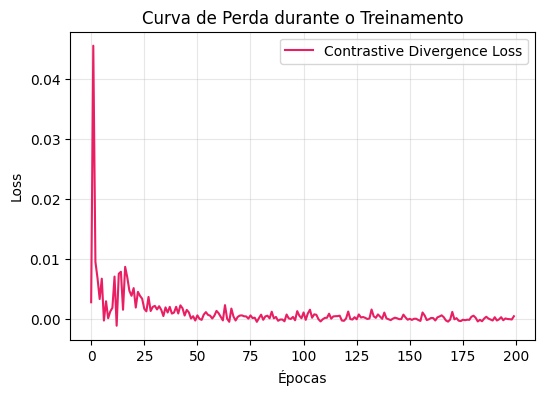

In [129]:
plt.figure(figsize=(6, 4))
plt.plot(losses_2d, color='#e91e63', label='Contrastive Divergence Loss')
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Curva de Perda durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

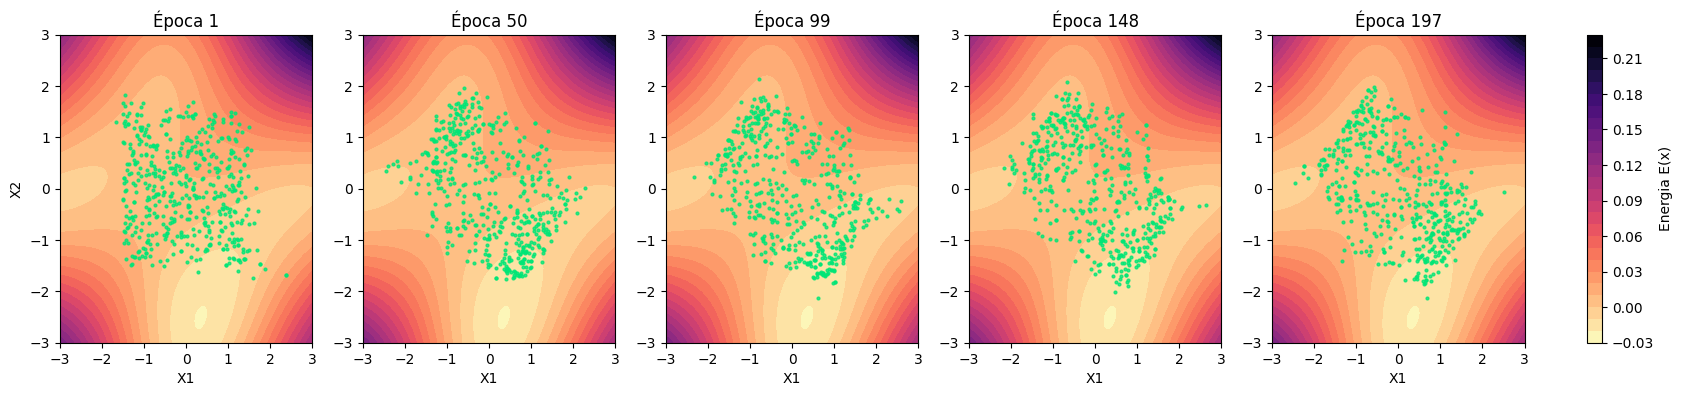

In [134]:
# Grid para o mapa de energia
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
grid = np.stack([X.ravel(), Y.ravel()], axis=1)

model_2d.eval()
with torch.no_grad():
    E = model_2d(torch.tensor(grid, dtype=torch.float32, device=device)).cpu().numpy().reshape(100, 100)

history = generated_samples_history[::49]

fig, axs = plt.subplots(1, len(history), figsize=(4 * len(history), 4))
axs = np.atleast_1d(axs)

for ax, (ep, samples) in zip(axs, history):
    c = ax.contourf(X, Y, E, levels=25, cmap="magma_r")
    ax.scatter(samples[:, 0], samples[:, 1], s=4, color="#00e676", alpha=0.8)
    ax.set_title(f"Época {ep}")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xlabel("X1")

axs[0].set_ylabel("X2")
fig.colorbar(c, ax=axs, fraction=0.015, pad=0.04, label="Energia E(x)")
plt.show()

## Aplicação em Imagens (MNIST)

Agora vamos escalar EBMs para modelar e gerar dados estruturados de maior dimensionalidade: imagens do **MNIST** ($28 \times 28 = 784$ dimensões).

### Preparação dos Dados

Carregaremos um subconjunto do MNIST para treinar nosso modelo de energia.

In [44]:
# Transformações para converter em Tensor e normalizar no intervalo [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Baixar e carregar o MNIST (usando subconjunto de 10k amostras para treinamento mais rápido)
train_dataset_full = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_dataset = torch.utils.data.Subset(train_dataset_full, range(10000))
mnist_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)

print(f"MNIST carregado: {len(train_dataset)} exemplos.")

MNIST carregado: 10000 exemplos.


### Buffer Persistente de Amostras

Para modelar o MNIST, utilizaremos a classe `SGLDBuffer` definida na seção do exemplo 2D, instanciando-a para imagens com formato `(1, 28, 28)` e limites no intervalo $[-1, 1]$. A intuição e o funcionamento são idênticos: sorteamos amostras do buffer, executamos SGLD por alguns passos, atualizamos o buffer e reinicializamos 5% delas com ruído uniforme.

### Arquitetura do Modelo

Implementamos um modelo de energia baseado em uma rede neural convolucional (**CNN**). A arquitetura recebe imagens de dimensão $1 \times 28 \times 28$ e passa por três camadas convolucionais com strides de $2$ (reduzindo progressivamente a resolução espacial para $14 \times 14$, $7 \times 7$ e depois $4 	imes 4$) e ativações `SiLU`. Por fim, a saída é achatada e passa por camadas lineares até resultar em uma única energia escalar de dimensão $1$.

In [45]:
class MNISTEnergyModel(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            # Entrada: batch_size x 1 x 28 x 28
            nn.Conv2d(1, hidden_dim, kernel_size=3, stride=2, padding=1),             # batch_size x hidden_dim x 14 x 14
            nn.SiLU(),
            nn.Conv2d(hidden_dim, hidden_dim * 2, kernel_size=3, stride=2, padding=1), # batch_size x (hidden_dim*2) x 7 x 7
            nn.SiLU(),
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, kernel_size=3, stride=2, padding=1), # batch_size x (hidden_dim*4) x 4 x 4
            nn.SiLU(),
            nn.Flatten(),
            nn.Linear(hidden_dim * 4 * 4 * 4, hidden_dim * 2),
            nn.SiLU(),
            nn.Linear(hidden_dim * 2, 1) # Saída de energia escalar
        )
        
    def forward(self, x):
        return self.net(x)

### Amostragem SGLD

O passo de amostragem realiza a retropropagação da energia em relação à própria imagem de entrada. Adicionalmente, clampar as intensidades dos pixels para o intervalo $[-1, 1]$ é de extrema importância para garantir imagens válidas.

In [46]:
def sgld_sample_mnist(model, x_start, steps=60, step_size=10.0, noise_std=0.005):
    """
    Gera amostras refinando x_start usando Langevin Dynamics convolucional.
    """
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
        
    x = x_start.clone().detach().requires_grad_(True)
    
    for _ in range(steps):
        energy = model(x)
        # Calcula o gradiente da energia com relação à imagem x
        grad = torch.autograd.grad(energy.sum(), x)[0]
        
        # Langevin step
        noise = torch.randn_like(x) * noise_std
        x.data = x.data - 0.5 * step_size * grad + noise
        # Clampar no intervalo [-1, 1]
        x.data = torch.clamp(x.data, -1.0, 1.0)
        
    for p in model.parameters():
        p.requires_grad = True
    model.train()
    return x.detach()

### Otimização e Treinamento

Instanciamos a rede convolucional, o buffer persistente e rodamos o loop de treinamento por $20$ épocas. Usaremos um limitador de norma de gradiente (`clip_grad_norm_`) para proteger o treinamento contra explosões repentinas no espaço de energia.

In [47]:
model_mnist = MNISTEnergyModel().to(device)
optimizer_mnist = optim.Adam(model_mnist.parameters(), lr=1e-4, weight_decay=1e-4)
buffer_mnist = SGLDBuffer(buffer_size=4096, shape=(1, 28, 28), range_min=-1.0, range_max=1.0)

In [48]:
num_epochs_mnist = 20
losses_mnist = []

for epoch in range(1, num_epochs_mnist + 1):
    epoch_loss = 0
    for real_imgs, _ in mnist_dataloader:
        real_imgs = real_imgs.to(device)
        batch_sz = real_imgs.shape[0]
        
        # Fase Negativa: Obter amostras de partida do buffer persistente
        x_start, indices = buffer_mnist.sample(batch_sz, device)
        
        # Executar amostragem SGLD rápida (60 passos)
        fake_imgs = sgld_sample_mnist(model_mnist, x_start, steps=60, step_size=10.0, noise_std=0.005)
        
        # Atualizar o buffer persistente com as imagens refinadas
        buffer_mnist.update(fake_imgs, indices)
        
        optimizer_mnist.zero_grad()
        
        energy_real = model_mnist(real_imgs)
        energy_fake = model_mnist(fake_imgs)
        
        # Contrastive Divergence Loss
        cd_loss = energy_real.mean() - energy_fake.mean()
        # Regularização L2 na energia para estabilização numérica
        reg_loss = 0.1 * (energy_real**2 + energy_fake**2).mean()
        
        loss = cd_loss + reg_loss
        loss.backward()
        
        # Estabiliza o gradiente da rede
        torch.nn.utils.clip_grad_norm_(model_mnist.parameters(), max_norm=5.0)
        optimizer_mnist.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(mnist_dataloader)
    losses_mnist.append(avg_loss)
    print(f"[{epoch}/{num_epochs_mnist}] Loss: {avg_loss:.4f}")

[1/20] Loss: -0.1680
[2/20] Loss: -0.0011
[3/20] Loss: 0.0060
[4/20] Loss: 0.0017
[5/20] Loss: -0.0058
[6/20] Loss: -0.0053
[7/20] Loss: -0.0061
[8/20] Loss: -0.0050
[9/20] Loss: -0.0068
[10/20] Loss: -0.0024
[11/20] Loss: -0.0025
[12/20] Loss: -0.0012
[13/20] Loss: -0.0019
[14/20] Loss: 0.0004
[15/20] Loss: -0.0012
[16/20] Loss: -0.0017
[17/20] Loss: -0.0013
[18/20] Loss: -0.0009
[19/20] Loss: -0.0004
[20/20] Loss: -0.0006


### Geração e Visualização

Vamos visualizar a curva de perda e, em seguida, amostrar e exibir algumas imagens resultantes do nosso buffer persistente.

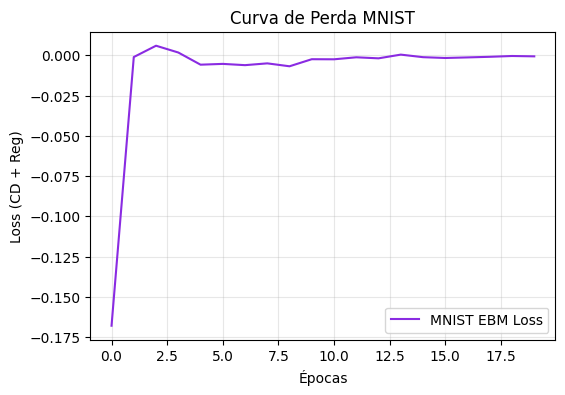

In [49]:
plt.figure(figsize=(6, 4))
plt.plot(losses_mnist, color='#8a2be2', label='MNIST EBM Loss')
plt.xlabel("Épocas")
plt.ylabel("Loss (CD + Reg)")
plt.title("Curva de Perda MNIST")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

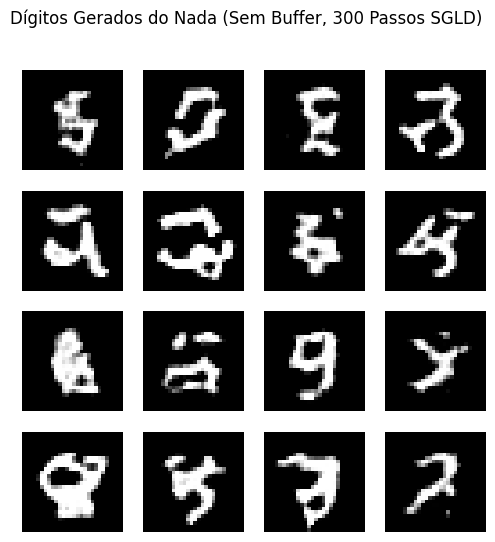

In [114]:
# Inicializar 16 amostras a partir de puro ruído uniforme no intervalo [-1, 1]
x_start = torch.rand(16, 1, 28, 28, device=device) * 2.0 - 1.0

# Executar amostragem SGLD independente com mais passos (ex: 300 passos)
generated_imgs = sgld_sample_mnist(model_mnist, x_start, steps=300, step_size=10.0, noise_std=0.005)

# Reescalar imagens de [-1, 1] para [0, 1] para o matplotlib
generated_imgs = (generated_imgs + 1.0) / 2.0
generated_imgs = torch.clamp(generated_imgs, 0.0, 1.0).cpu()

# Plotar a grade de imagens
fig, axs = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axs.flat):
    ax.imshow(generated_imgs[i].squeeze(), cmap='gray')
    ax.axis('off')
    
plt.suptitle("Dígitos Gerados do Nada (Sem Buffer, 300 Passos SGLD)")
plt.show()

## Exercícios

### Exercício 1
Utilize a função `sgld_sample_mnist` modificando o hiperparâmetro `steps`. Em vez dos $60$ passos originais, tente realizar amostragem com $10$ passos e depois com $150$ passos de Langevin (começando de puro ruído). Comente os efeitos que o número de passos exerce na fidelidade dos traços desenhados.

### Exercício 2
Substitua as ativações `SiLU` do modelo `EnergyModel2D` pela função `ReLU`. Treine a rede por $100$ épocas e execute novamente o plot da superfície tridimensional de energia. O que mudou visualmente no relevo das curvas de nível de energia comparado ao uso da ativação contínua `SiLU`?